# Sampling Parameter Sweep — Accuracy Analysis

Investigates how vLLM sampling parameters affect LLM vulnerability detection accuracy.
Covers **19 parameter configurations** of Qwen3-4B across **4 datasets**:
CASTLE, CVEFixes (C), CVEFixes (Python), JitVul.

Swept parameters: `temperature`, `min_p`, `top_k`, `top_p`, `presence_penalty`, `repeat_penalty`

Key questions:
- Which parameter type has the greatest impact on accuracy and FNR?
- Which specific values improve or degrade detection performance?
- Are parameter effects consistent across datasets?

In [1]:
import json
import math
import re
from pathlib import Path

import matplotlib
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style='whitegrid', palette='muted')
matplotlib.rcParams['figure.dpi'] = 120

In [2]:
## Configuration

PROJECT_ROOT = Path('__file__').resolve().parent.parent

RESULTS = {
    'castle':   PROJECT_ROOT / 'results' / 'castle_experiments'   / 'experiment_plan_results.json',
    'cvefixes': PROJECT_ROOT / 'results' / 'cvefixes_experiments' / 'experiment_plan_results.json',
    'jitvul':   PROJECT_ROOT / 'results' / 'jitvul_experiments'   / 'experiment_plan_results.json',
}

# model_name suffix (after stripping 'qwen3-4b-') -> (param_type, param_value)
PARAM_MAP = {
    'base':         ('baseline',         float('nan')),
    'temp-00':      ('temperature',      0.00),
    'temp-03':      ('temperature',      0.30),
    'temp-09':      ('temperature',      0.90),
    'min-p-002':    ('min_p',            0.02),
    'min-p-005':    ('min_p',            0.05),
    'min-p-010':    ('min_p',            0.10),
    'top-k-020':    ('top_k',           20.00),
    'top-k-040':    ('top_k',           40.00),
    'top-k-080':    ('top_k',           80.00),
    'top-p-080':    ('top_p',            0.80),
    'top-p-090':    ('top_p',            0.90),
    'top-p-095':    ('top_p',            0.95),
    'presence-025': ('presence_penalty', 0.25),
    'presence-050': ('presence_penalty', 0.50),
    'presence-100': ('presence_penalty', 1.00),
    'repeat-105':   ('repeat_penalty',   1.05),
    'repeat-110':   ('repeat_penalty',   1.10),
    'repeat-120':   ('repeat_penalty',   1.20),
}

PARAM_TYPE_DISPLAY = {
    'temperature':      'Temperature',
    'min_p':            'Min-P',
    'top_k':            'Top-K',
    'top_p':            'Top-P',
    'presence_penalty': 'Presence Penalty',
    'repeat_penalty':   'Repeat Penalty',
    'baseline':         'Baseline',
}

DATASET_DISPLAY = {
    'castle':          'CASTLE',
    'cvefixes_c':      'CVEFixes (C)',
    'cvefixes_python': 'CVEFixes (Python)',
    'jitvul':          'JitVul',
}

DATASETS_ORDERED    = ['castle', 'cvefixes_c', 'cvefixes_python', 'jitvul']
PARAM_TYPES_ORDERED = ['temperature', 'min_p', 'top_k', 'top_p', 'presence_penalty', 'repeat_penalty']

DATASET_COLORS = {
    'castle':          '#4e79a7',
    'cvefixes_c':      '#f28e2b',
    'cvefixes_python': '#e15759',
    'jitvul':          '#59a14f',
}

PARAM_TYPE_COLORS = {
    'temperature':      '#4e79a7',
    'min_p':            '#f28e2b',
    'top_k':            '#e15759',
    'top_p':            '#59a14f',
    'presence_penalty': '#b07aa1',
    'repeat_penalty':   '#ff9da7',
    'baseline':         '#9c755f',
}

In [3]:
## Data loading + derived metrics
## Multiple runs of the same config are aggregated by summing confusion matrices
## and recomputing all metrics from the combined totals.

def _dataset_key(path: str) -> str:
    if 'castle' in path:
        return 'castle'
    if 'jitvul' in path:
        return 'jitvul'
    if 'cvefixes' in path:
        return 'cvefixes_python' if 'python' in path else 'cvefixes_c'
    raise ValueError(f'Unknown dataset path: {path}')


def _parse_param(model_name: str) -> tuple:
    remainder = re.sub(r'^qwen3-4b-', '', model_name)
    return PARAM_MAP.get(remainder, ('unknown', float('nan')))


def _recompute_metrics(tp: int, tn: int, fp: int, fn: int) -> dict:
    """Compute all classification metrics from raw confusion matrix counts."""
    n    = tp + tn + fp + fn
    rec  = tp / (tp + fn) if (tp + fn) else 0.0
    prec = tp / (tp + fp) if (tp + fp) else 0.0
    spec = tn / (tn + fp) if (tn + fp) else 0.0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) else 0.0
    denom = math.sqrt((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn))
    mcc   = (tp * tn - fp * fn) / denom if denom else 0.0
    return dict(
        accuracy=(tp + tn) / n if n else 0.0,
        precision=prec, recall=rec, f1=f1, specificity=spec, MCC=mcc,
    )


rows = []
for results_file in RESULTS.values():
    with open(results_file) as f:
        raw = json.load(f)
    for exp in raw['experiments']:
        if not exp['is_success']:
            continue
        bi = exp['benchmark_info']
        m  = exp['metrics']
        cm = m['details']['confusion_matrix']
        ts = bi.get('tokens_used_stats', {})
        ps = bi.get('processing_time_stats', {})
        param_type, param_value = _parse_param(bi['model_name'])
        rows.append({
            'model_name':    bi['model_name'],
            'dataset':       _dataset_key(bi['dataset_path']),
            'param_type':    param_type,
            'param_value':   param_value,
            'TP':            cm['true_positives'],
            'TN':            cm['true_negatives'],
            'FP':            cm['false_positives'],
            'FN':            cm['false_negatives'],
            'tokens_avg':    ts.get('mean',  bi.get('tokens_used_avg',      float('nan'))),
            'tokens_std':    ts.get('std',                                   float('nan')),
            'time_avg':      ps.get('mean',  bi.get('avg_time_per_sample',   float('nan'))),
            'total_samples': bi['total_samples'],
        })

raw_df = pd.DataFrame(rows)

# Aggregate multiple runs: sum confusion matrices, average timing stats
def _agg_group(g):
    tp, tn = int(g['TP'].sum()), int(g['TN'].sum())
    fp, fn = int(g['FP'].sum()), int(g['FN'].sum())
    return pd.Series({
        'model_name':    g['model_name'].iloc[0],
        'dataset':       g['dataset'].iloc[0],
        'param_type':    g['param_type'].iloc[0],
        'param_value':   g['param_value'].iloc[0],
        'TP':            tp,
        'TN':            tn,
        'FP':            fp,
        'FN':            fn,
        'tokens_avg':    g['tokens_avg'].mean(),
        'tokens_std':    g['tokens_std'].mean(),
        'time_avg':      g['time_avg'].mean(),
        'total_samples': int(g['total_samples'].sum()),
        'n_runs':        len(g),
        **_recompute_metrics(tp, tn, fp, fn),
    })

df = (
    raw_df
    .groupby(['model_name', 'dataset'], sort=False)
    .apply(_agg_group)
    .reset_index(drop=True)
)

# Report aggregation
multi = df[df['n_runs'] > 1][['model_name', 'dataset', 'n_runs']]
print(f'Raw experiment entries     : {len(raw_df)}')
print(f'Unique configs (aggregated): {len(df)}')
if not multi.empty:
    print(f'Configs with >1 run (confusion matrices summed across runs):')
    print(multi.sort_values('n_runs', ascending=False).to_string(index=False))

# Derived metrics
df['FNR']               = 1 - df['recall']
df['FPR']               = 1 - df['specificity']
df['balanced_accuracy'] = (df['recall'] + df['specificity']) / 2
df['youden_j']          = df['recall'] + df['specificity'] - 1
df['dataset_label']     = df['dataset'].map(DATASET_DISPLAY)
df['param_label']       = df['model_name'].str.replace('qwen3-4b-', '', regex=False)

# Attach per-dataset baseline values for delta computation
bl = (
    df[df['param_type'] == 'baseline']
    [['dataset', 'accuracy', 'FNR', 'balanced_accuracy', 'MCC']]
    .rename(columns={'accuracy': 'bl_acc', 'FNR': 'bl_fnr',
                     'balanced_accuracy': 'bl_bacc', 'MCC': 'bl_mcc'})
)
df = df.merge(bl, on='dataset', how='left')
df['delta_acc']  = df['accuracy']          - df['bl_acc']
df['delta_fnr']  = df['FNR']               - df['bl_fnr']
df['delta_bacc'] = df['balanced_accuracy'] - df['bl_bacc']
df['delta_mcc']  = df['MCC']               - df['bl_mcc']

print(f'\nDatasets    : {sorted(df["dataset"].unique())}')
print(f'Param types : {sorted(df["param_type"].unique())}')
df.groupby(['dataset', 'param_type']).size().unstack(fill_value=0)

Raw experiment entries     : 115
Unique configs (aggregated): 76
Configs with >1 run (confusion matrices summed across runs):
           model_name         dataset  n_runs
        qwen3-4b-base          castle       2
        qwen3-4b-base cvefixes_python       2
     qwen3-4b-temp-09      cvefixes_c       2
   qwen3-4b-top-k-020      cvefixes_c       2
   qwen3-4b-top-k-040      cvefixes_c       2
   qwen3-4b-top-k-080      cvefixes_c       2
   qwen3-4b-top-p-080      cvefixes_c       2
   qwen3-4b-top-p-090      cvefixes_c       2
   qwen3-4b-top-p-095      cvefixes_c       2
     qwen3-4b-temp-00 cvefixes_python       2
     qwen3-4b-temp-00      cvefixes_c       2
     qwen3-4b-temp-03 cvefixes_python       2
     qwen3-4b-temp-09 cvefixes_python       2
   qwen3-4b-top-k-020 cvefixes_python       2
   qwen3-4b-top-k-040 cvefixes_python       2
   qwen3-4b-top-k-080 cvefixes_python       2
   qwen3-4b-top-p-080 cvefixes_python       2
   qwen3-4b-top-p-090 cvefixes_python       2


/var/folders/cy/xkclg4xd0gjglf9yxn33fv6r0000gn/T/ipykernel_9236/1514987535.py:89: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_agg_group)


param_type,baseline,min_p,presence_penalty,repeat_penalty,temperature,top_k,top_p
dataset,,,,,,,
castle,1,3,3,3,3,3,3
cvefixes_c,1,3,3,3,3,3,3
cvefixes_python,1,3,3,3,3,3,3
jitvul,1,3,3,3,3,3,3


## Overview

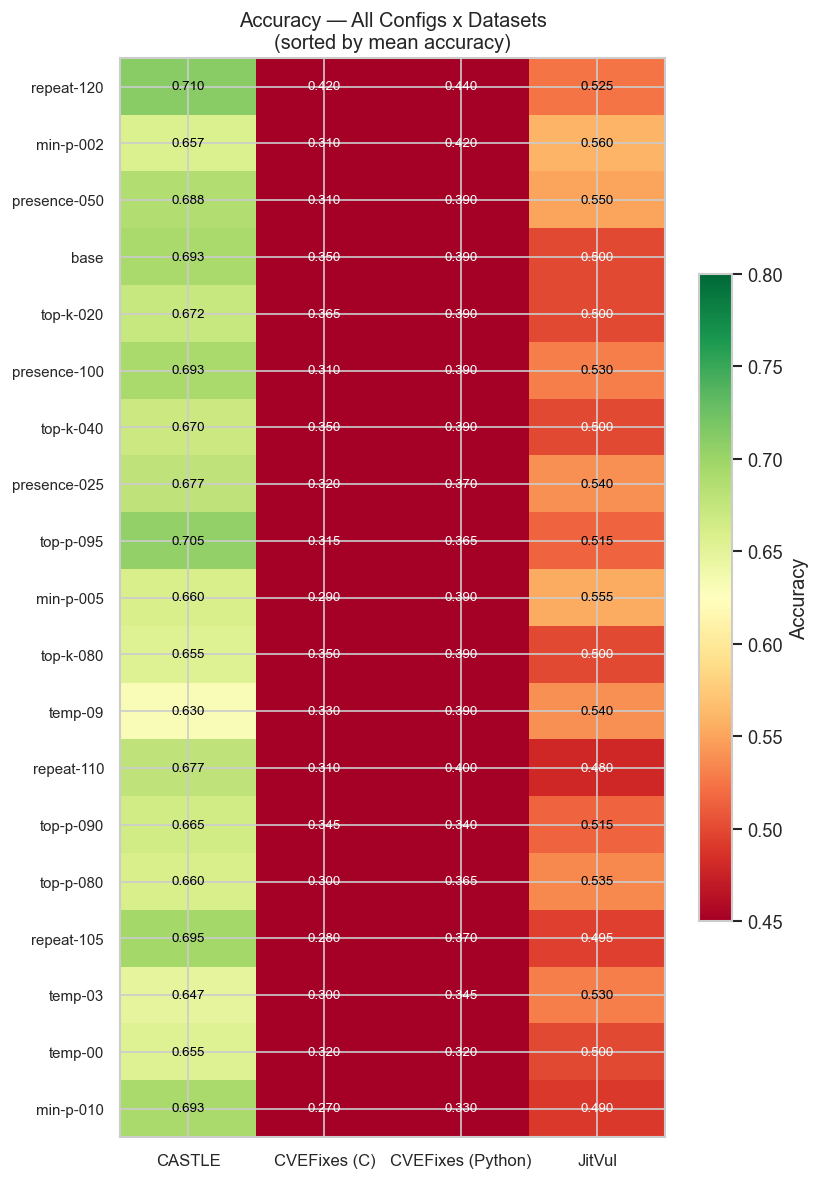

In [4]:
## Accuracy heatmap — all configs x all datasets (sorted by mean accuracy)

pivot = (
    df[df['param_type'] != 'unknown']
    .pivot_table(index='param_label', columns='dataset', values='accuracy', aggfunc='first')
    .reindex(columns=DATASETS_ORDERED)
)
pivot = pivot.loc[pivot.mean(axis=1).sort_values(ascending=False).index]
pivot.columns = [DATASET_DISPLAY[c] for c in pivot.columns]
pivot.index.name = 'Config'

fig, ax = plt.subplots(figsize=(7, 10))
im = ax.imshow(pivot.values.astype(float), cmap='RdYlGn', vmin=0.45, vmax=0.80, aspect='auto')
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, fontsize=10)
ax.set_yticks(range(len(pivot)))
ax.set_yticklabels(pivot.index, fontsize=9)
ax.set_title('Accuracy — All Configs x Datasets\n(sorted by mean accuracy)', fontsize=12)
for i in range(len(pivot)):
    for j in range(len(pivot.columns)):
        v = pivot.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f'{v:.3f}', ha='center', va='center', fontsize=8,
                    color='black' if 0.5 < v < 0.72 else 'white')
plt.colorbar(im, ax=ax, shrink=0.6, label='Accuracy')
fig.tight_layout()
plt.show()

## Parameter Type Impact

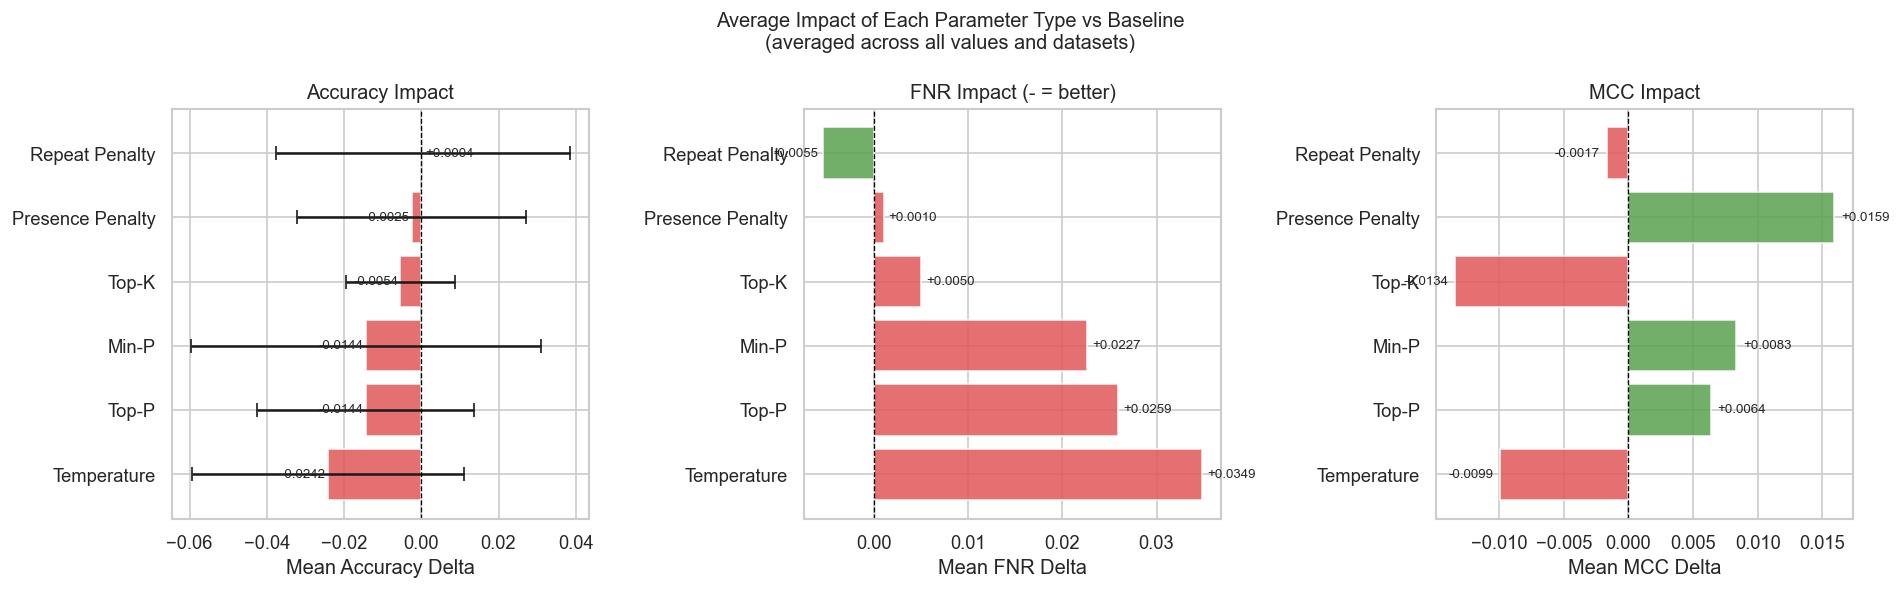

,Param Type,mean_acc,mean_delta_acc,std_delta_acc,max_delta_acc,min_delta_acc,mean_delta_fnr,mean_delta_mcc
0,Temperature,0.4590,-0.0242,+0.0351,+0.0400,-0.0700,+0.0349,-0.0099
1,Top-P,0.4688,-0.0144,+0.0281,+0.0350,-0.0500,+0.0259,+0.0064
2,Min-P,0.4688,-0.0144,+0.0454,+0.0600,-0.0800,+0.0227,+0.0083
3,Top-K,0.4777,-0.0054,+0.0141,+0.0150,-0.0375,+0.0050,-0.0134
4,Presence Penalty,0.4806,-0.0025,+0.0297,+0.0500,-0.0400,+0.0010,+0.0159
5,Repeat Penalty,0.4835,+0.0004,+0.0381,+0.0700,-0.0700,-0.0055,-0.0017


In [5]:
## Which parameter type moves the needle most? (avg delta vs baseline across all values and datasets)

sweep_df = df[df['param_type'].isin(PARAM_TYPES_ORDERED)].copy()

pt_summary = (
    sweep_df
    .groupby('param_type')
    .agg(
        mean_acc      =('accuracy',   'mean'),
        mean_delta_acc=('delta_acc',  'mean'),
        std_delta_acc =('delta_acc',  'std'),
        max_delta_acc =('delta_acc',  'max'),
        min_delta_acc =('delta_acc',  'min'),
        mean_delta_fnr=('delta_fnr',  'mean'),
        mean_delta_mcc=('delta_mcc',  'mean'),
    )
    .reset_index()
)
pt_summary['label'] = pt_summary['param_type'].map(PARAM_TYPE_DISPLAY)
pt_summary = pt_summary.sort_values('mean_delta_acc', ascending=True).reset_index(drop=True)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (col, xlabel, title, flip_green) in zip(axes, [
    ('mean_delta_acc', 'Mean Accuracy Delta',        'Accuracy Impact',         False),
    ('mean_delta_fnr', 'Mean FNR Delta',             'FNR Impact (- = better)', True),
    ('mean_delta_mcc', 'Mean MCC Delta',             'MCC Impact',              False),
]):
    vals   = pt_summary[col].values
    colors = []
    for v in vals:
        if flip_green:
            colors.append('#59a14f' if v <= 0 else '#e15759')
        else:
            colors.append('#59a14f' if v >= 0 else '#e15759')
    ax.barh(pt_summary['label'], vals, color=colors, alpha=0.85,
            xerr=pt_summary.get('std_delta_acc') if col == 'mean_delta_acc' else None,
            capsize=4)
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xlabel(xlabel)
    ax.set_title(title)
    for i, v in enumerate(vals):
        ax.text(v + (5e-4 if v >= 0 else -5e-4), i,
                f'{v:+.4f}', va='center', ha='left' if v >= 0 else 'right', fontsize=8)

fig.suptitle('Average Impact of Each Parameter Type vs Baseline\n(averaged across all values and datasets)',
             fontsize=12)
fig.tight_layout()
plt.show()

display(
    pt_summary[['label', 'mean_acc', 'mean_delta_acc', 'std_delta_acc',
                'max_delta_acc', 'min_delta_acc', 'mean_delta_fnr', 'mean_delta_mcc']]
    .rename(columns={'label': 'Param Type'})
    .round(4)
    .style
    .background_gradient(subset=['mean_delta_acc', 'mean_delta_mcc'], cmap='RdYlGn', axis=0)
    .background_gradient(subset=['mean_delta_fnr'], cmap='RdYlGn_r', axis=0)
    .format('{:+.4f}', subset=['mean_delta_acc', 'std_delta_acc', 'max_delta_acc',
                               'min_delta_acc', 'mean_delta_fnr', 'mean_delta_mcc'])
    .format('{:.4f}', subset=['mean_acc'])
)

## Accuracy vs Parameter Value

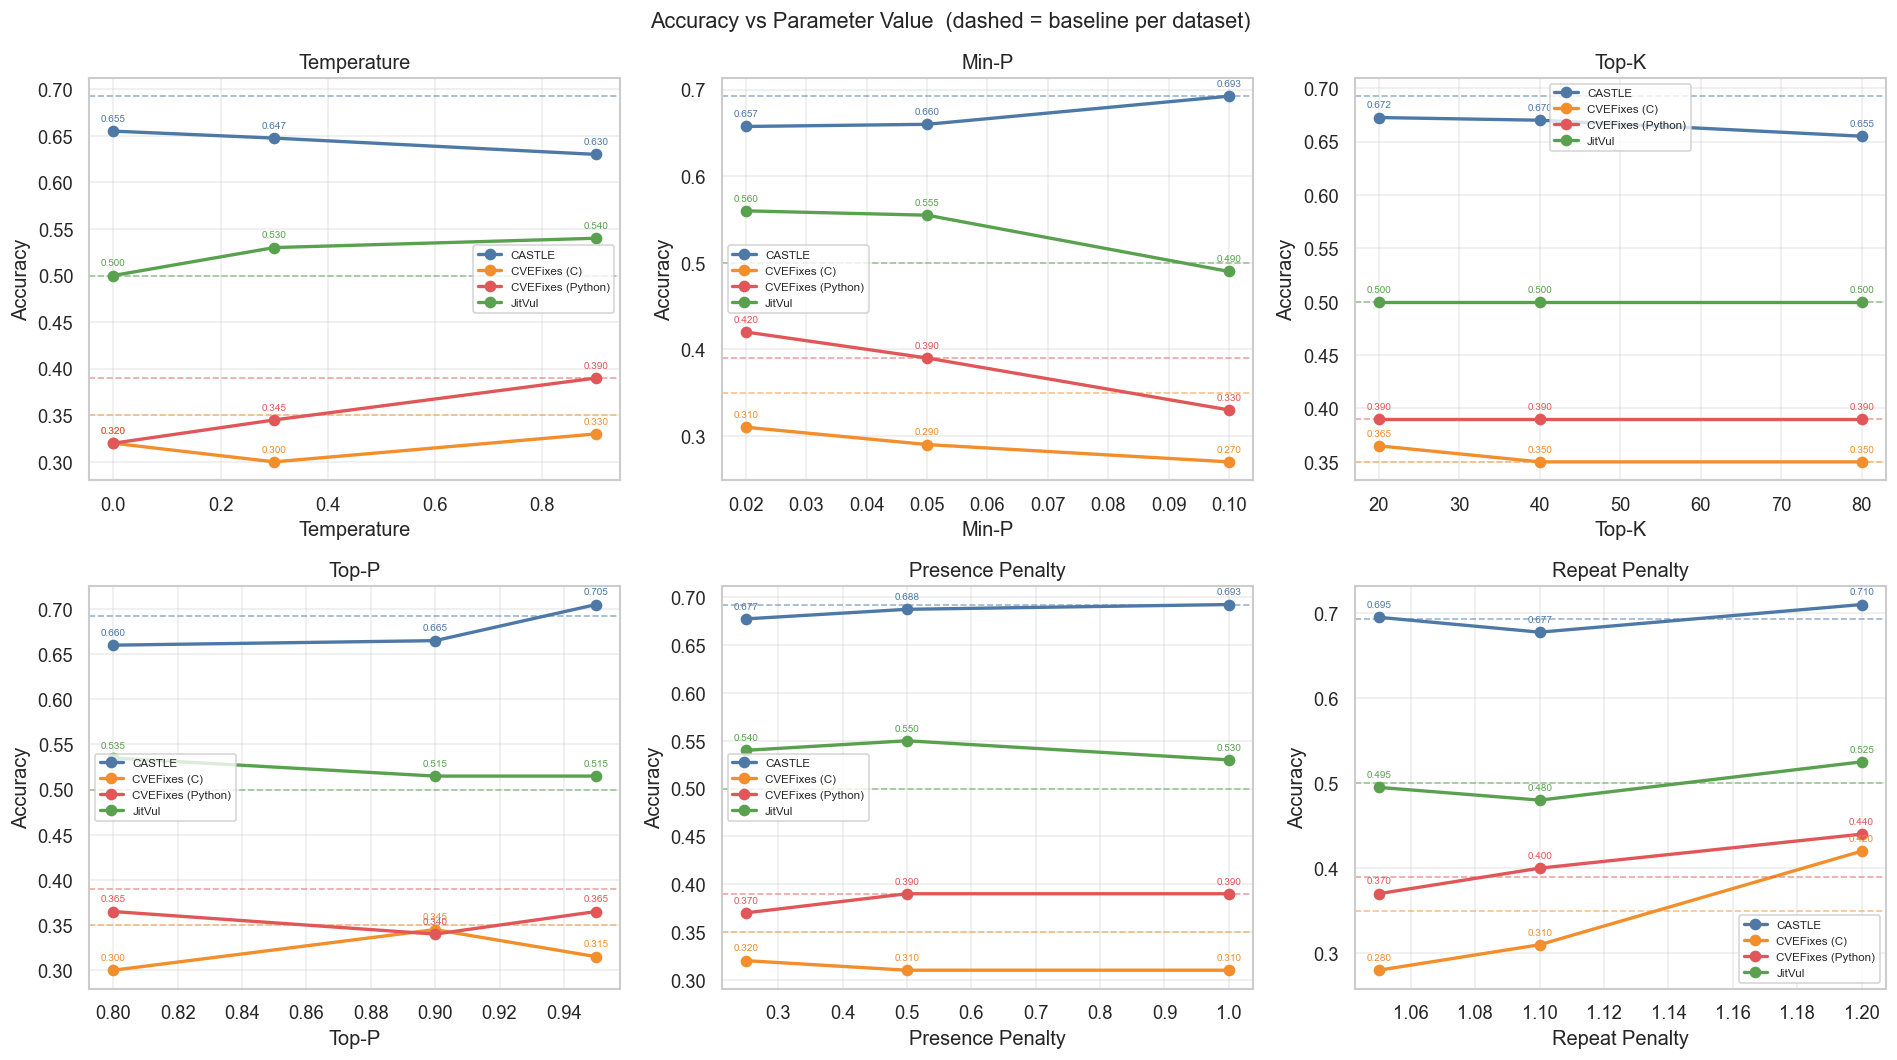

In [6]:
## Accuracy vs parameter value — 2x3 grid, one panel per parameter type
## Dashed horizontal lines = baseline accuracy per dataset

baseline_by_ds = df[df['param_type'] == 'baseline'].set_index('dataset')[['accuracy', 'FNR']]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for ax, param_type in zip(axes.flat, PARAM_TYPES_ORDERED):
    sub = df[df['param_type'] == param_type].sort_values('param_value')
    for ds in DATASETS_ORDERED:
        ds_sub = sub[sub['dataset'] == ds].sort_values('param_value')
        if ds_sub.empty:
            continue
        ax.plot(ds_sub['param_value'], ds_sub['accuracy'],
                marker='o', linewidth=2, markersize=6,
                label=DATASET_DISPLAY[ds], color=DATASET_COLORS[ds])
        # Annotate each point with its config label
        for _, row in ds_sub.iterrows():
            ax.annotate(f"{row['accuracy']:.3f}",
                        (row['param_value'], row['accuracy']),
                        textcoords='offset points', xytext=(0, 6),
                        ha='center', fontsize=6, color=DATASET_COLORS[ds])
        # Baseline reference line
        if ds in baseline_by_ds.index:
            ax.axhline(baseline_by_ds.loc[ds, 'accuracy'],
                       color=DATASET_COLORS[ds], linestyle='--', linewidth=1, alpha=0.55)

    ax.set_xlabel(PARAM_TYPE_DISPLAY[param_type])
    ax.set_ylabel('Accuracy')
    ax.set_title(PARAM_TYPE_DISPLAY[param_type])
    ax.legend(fontsize=7, loc='best')
    ax.grid(True, alpha=0.35)

fig.suptitle('Accuracy vs Parameter Value  (dashed = baseline per dataset)', fontsize=13)
fig.tight_layout()
plt.show()

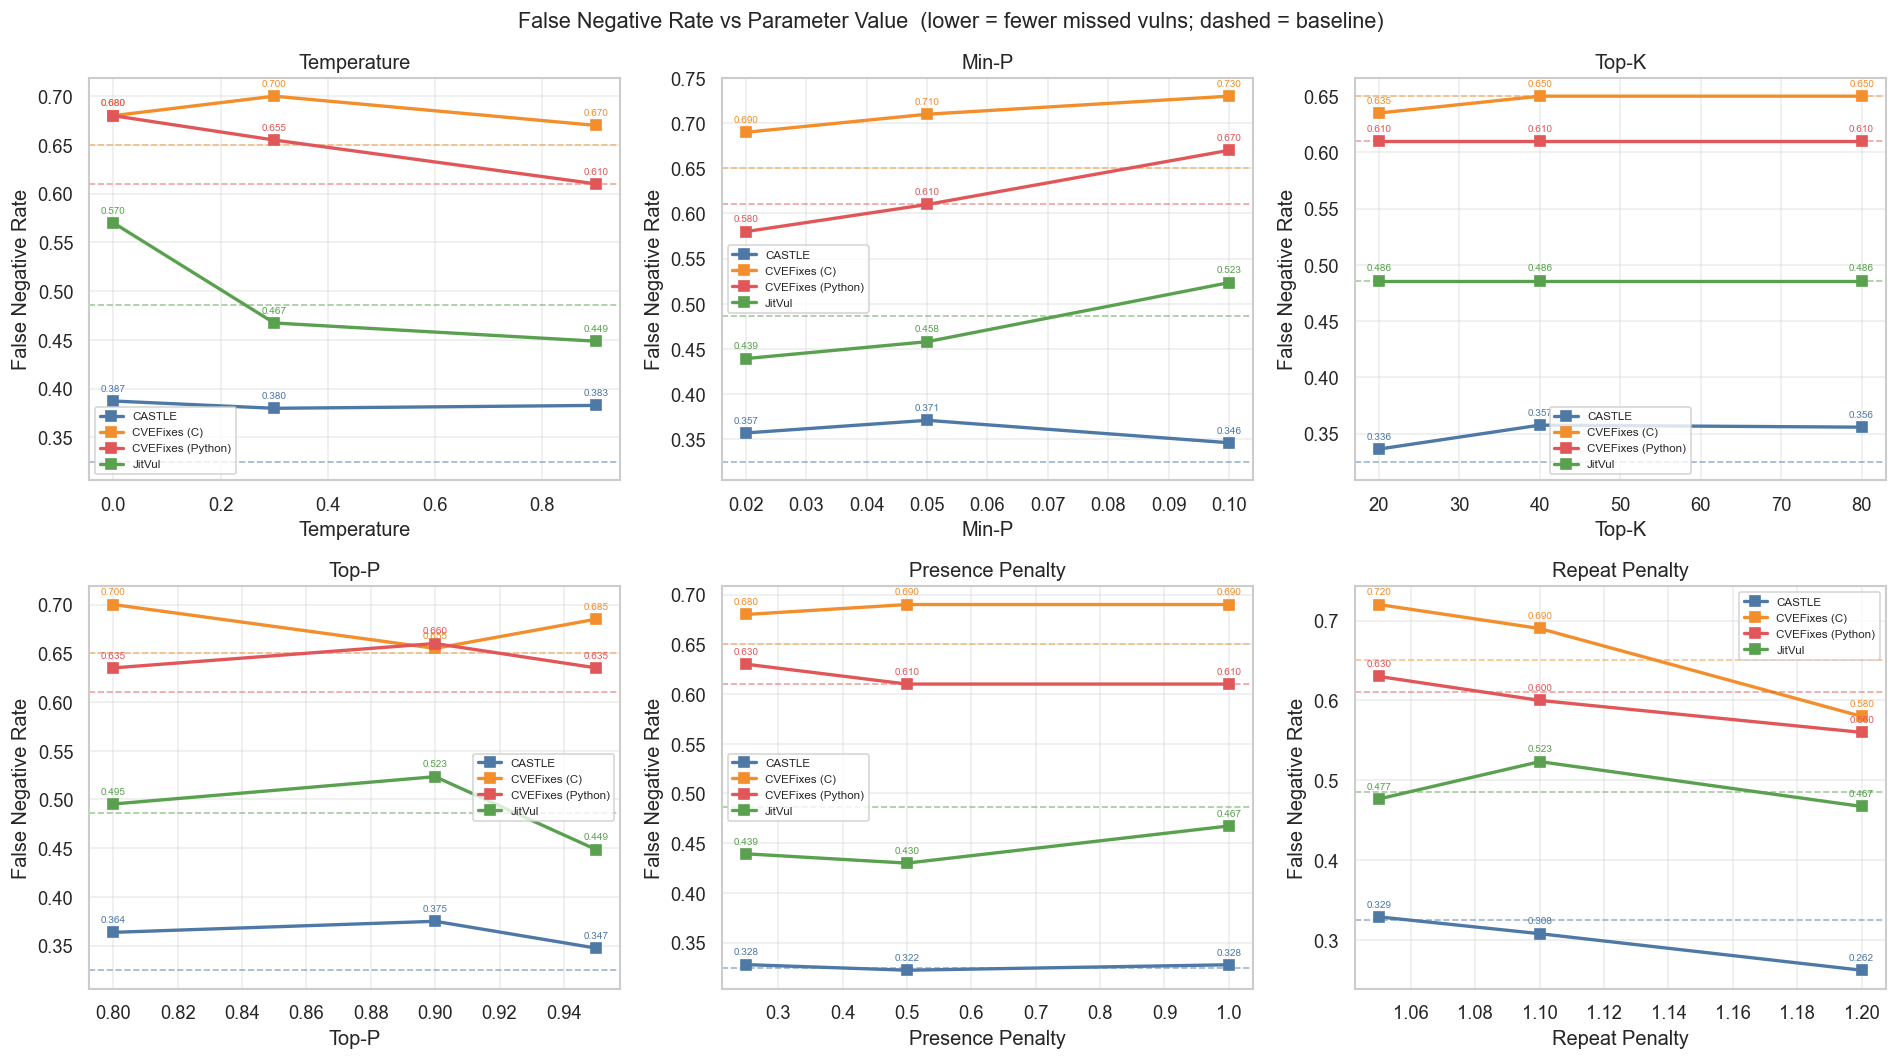

In [7]:
## False Negative Rate vs parameter value — same layout as accuracy chart
## Lower FNR = fewer missed vulnerabilities (better for security)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for ax, param_type in zip(axes.flat, PARAM_TYPES_ORDERED):
    sub = df[df['param_type'] == param_type].sort_values('param_value')
    for ds in DATASETS_ORDERED:
        ds_sub = sub[sub['dataset'] == ds].sort_values('param_value')
        if ds_sub.empty:
            continue
        ax.plot(ds_sub['param_value'], ds_sub['FNR'],
                marker='s', linewidth=2, markersize=6,
                label=DATASET_DISPLAY[ds], color=DATASET_COLORS[ds])
        for _, row in ds_sub.iterrows():
            ax.annotate(f"{row['FNR']:.3f}",
                        (row['param_value'], row['FNR']),
                        textcoords='offset points', xytext=(0, 6),
                        ha='center', fontsize=6, color=DATASET_COLORS[ds])
        if ds in baseline_by_ds.index:
            ax.axhline(baseline_by_ds.loc[ds, 'FNR'],
                       color=DATASET_COLORS[ds], linestyle='--', linewidth=1, alpha=0.55)

    ax.set_xlabel(PARAM_TYPE_DISPLAY[param_type])
    ax.set_ylabel('False Negative Rate')
    ax.set_title(PARAM_TYPE_DISPLAY[param_type])
    ax.legend(fontsize=7, loc='best')
    ax.grid(True, alpha=0.35)

fig.suptitle('False Negative Rate vs Parameter Value  (lower = fewer missed vulns; dashed = baseline)',
             fontsize=13)
fig.tight_layout()
plt.show()

## Delta from Baseline

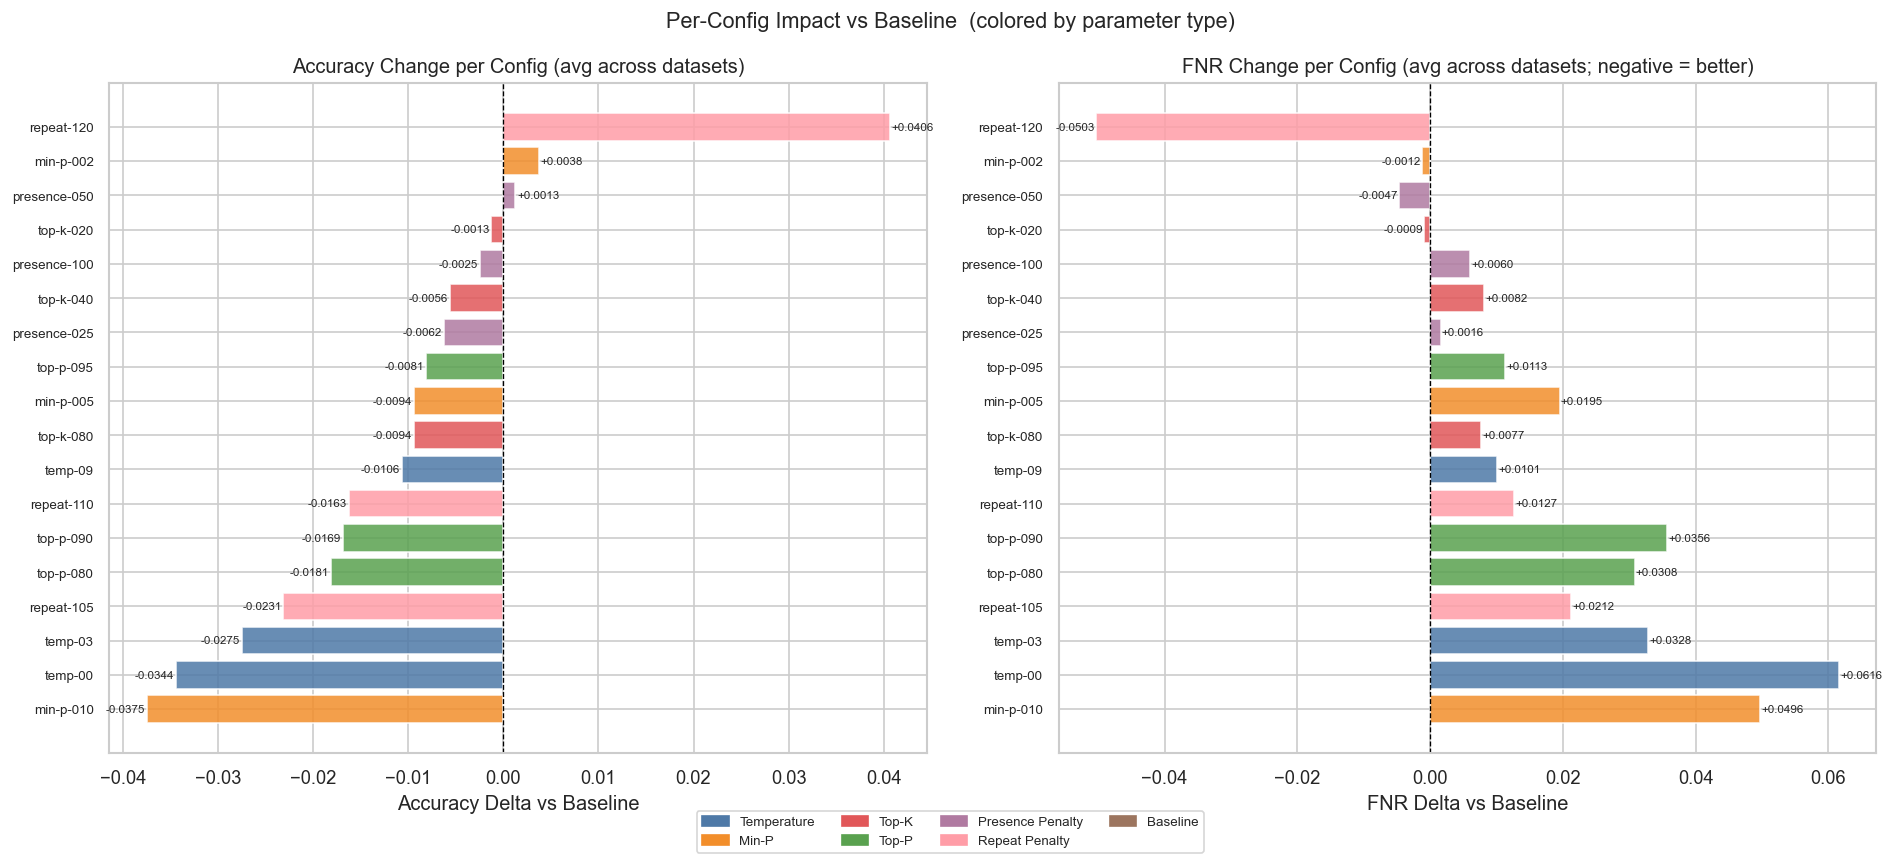

In [8]:
## Average accuracy delta per config (averaged across datasets) — horizontal bar chart

avg_delta = (
    df[df['param_type'] != 'baseline']
    .groupby('param_label')[['delta_acc', 'delta_fnr', 'delta_bacc', 'delta_mcc']]
    .mean()
    .reset_index()
)
avg_delta['param_type'] = avg_delta['param_label'].apply(
    lambda x: _parse_param('qwen3-4b-' + x)[0]
)
avg_delta = avg_delta.sort_values('delta_acc', ascending=True).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, (col, xlabel, title, flip) in zip(axes, [
    ('delta_acc', 'Accuracy Delta vs Baseline',
     'Accuracy Change per Config (avg across datasets)', False),
    ('delta_fnr', 'FNR Delta vs Baseline',
     'FNR Change per Config (avg across datasets; negative = better)', True),
]):
    colors = [
        PARAM_TYPE_COLORS.get(pt, '#aaa')
        for pt in avg_delta['param_type']
    ]
    ax.barh(avg_delta['param_label'], avg_delta[col], color=colors, alpha=0.85)
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xlabel(xlabel)
    ax.set_title(title)
    ax.tick_params(axis='y', labelsize=8)
    for i, (_, row) in enumerate(avg_delta.iterrows()):
        v = row[col]
        ax.text(v + (2e-4 if v >= 0 else -2e-4), i,
                f'{v:+.4f}', va='center', ha='left' if v >= 0 else 'right', fontsize=7)

# Legend by param type
patches = [mpatches.Patch(color=PARAM_TYPE_COLORS[pt], label=PARAM_TYPE_DISPLAY[pt])
           for pt in PARAM_TYPES_ORDERED]
patches.append(mpatches.Patch(color='#9c755f', label='Baseline'))
fig.legend(handles=patches, loc='lower center', ncol=4, fontsize=8,
           bbox_to_anchor=(0.5, -0.03))

fig.suptitle('Per-Config Impact vs Baseline  (colored by parameter type)', fontsize=13)
fig.tight_layout()
plt.show()

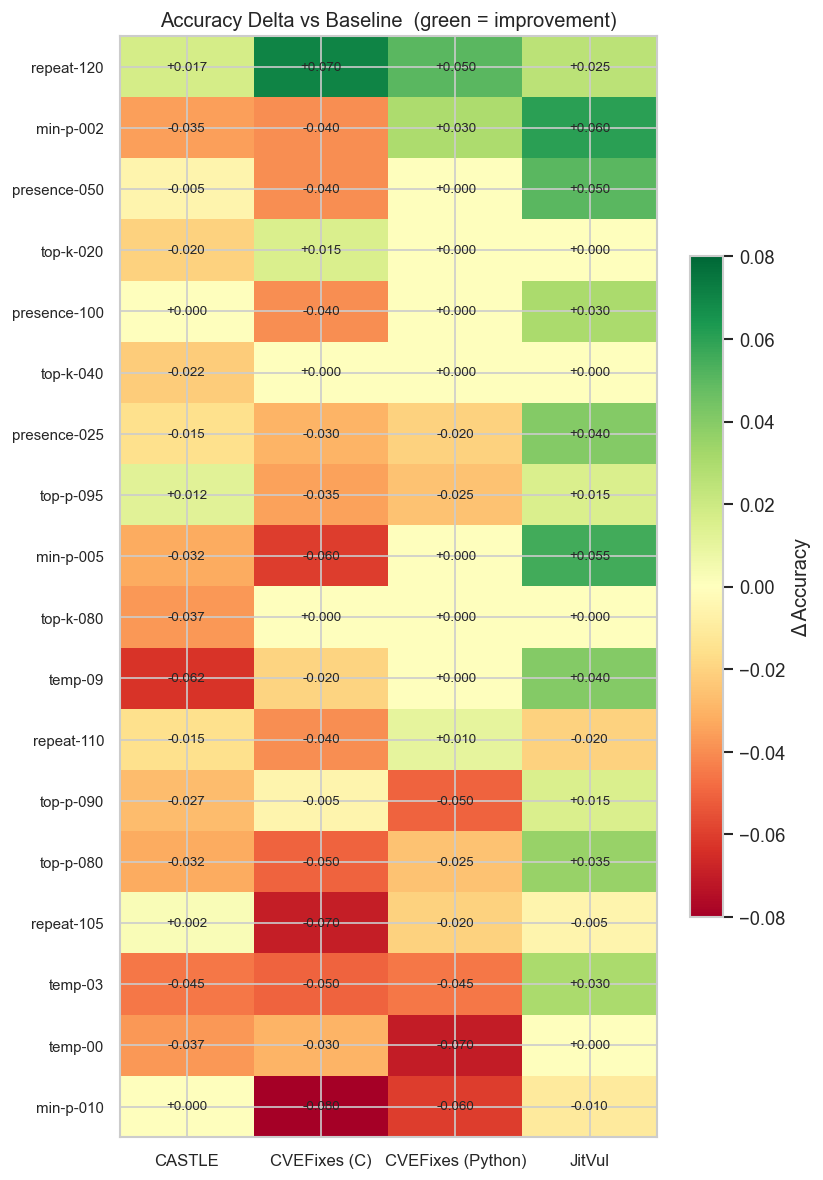

In [9]:
## Delta heatmap — accuracy change per config x dataset (green = improvement over baseline)

delta_pivot = (
    df[df['param_type'] != 'baseline']
    .pivot_table(index='param_label', columns='dataset', values='delta_acc', aggfunc='first')
    .reindex(columns=DATASETS_ORDERED)
)
delta_pivot = delta_pivot.loc[delta_pivot.mean(axis=1).sort_values(ascending=False).index]
delta_pivot.columns = [DATASET_DISPLAY[c] for c in delta_pivot.columns]

vmax = max(abs(float(np.nanmax(delta_pivot.values))),
           abs(float(np.nanmin(delta_pivot.values))), 0.03)

fig, ax = plt.subplots(figsize=(7, 10))
im = ax.imshow(delta_pivot.values.astype(float), cmap='RdYlGn',
               vmin=-vmax, vmax=vmax, aspect='auto')
ax.set_xticks(range(len(delta_pivot.columns)))
ax.set_xticklabels(delta_pivot.columns, fontsize=10)
ax.set_yticks(range(len(delta_pivot)))
ax.set_yticklabels(delta_pivot.index, fontsize=9)
ax.set_title('Accuracy Delta vs Baseline  (green = improvement)', fontsize=12)
for i in range(len(delta_pivot)):
    for j in range(len(delta_pivot.columns)):
        v = delta_pivot.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f'{v:+.3f}', ha='center', va='center', fontsize=8)
plt.colorbar(im, ax=ax, shrink=0.6, label='\u0394 Accuracy')
fig.tight_layout()
plt.show()

## Best Configuration per Parameter Type

In [10]:
## For each parameter type x dataset: which value gives best accuracy?

best_rows = []
for param_type in PARAM_TYPES_ORDERED:
    for ds in DATASETS_ORDERED:
        sub = df[(df['param_type'] == param_type) & (df['dataset'] == ds)]
        if sub.empty:
            continue
        best = sub.loc[sub['accuracy'].idxmax()]
        worst = sub.loc[sub['accuracy'].idxmin()]
        best_rows.append({
            'Param Type':     PARAM_TYPE_DISPLAY[param_type],
            'Dataset':        DATASET_DISPLAY[ds],
            'Best Value':     best['param_value'],
            'Best Config':    best['param_label'],
            'Best Accuracy':  best['accuracy'],
            'Baseline Acc':   best['bl_acc'],
            'Best Delta':     best['delta_acc'],
            'Worst Value':    worst['param_value'],
            'Worst Accuracy': worst['accuracy'],
            'Worst Delta':    worst['delta_acc'],
            'Best FNR':       best['FNR'],
            'Baseline FNR':   best['bl_fnr'],
        })

best_df = pd.DataFrame(best_rows)

display(
    best_df.style
    .background_gradient(subset=['Best Delta', 'Worst Delta'], cmap='RdYlGn', axis=None,
                         vmin=-0.08, vmax=0.08)
    .format({
        'Best Value':     '{:.3f}',
        'Best Accuracy':  '{:.3f}',
        'Baseline Acc':   '{:.3f}',
        'Best Delta':     '{:+.3f}',
        'Worst Value':    '{:.3f}',
        'Worst Accuracy': '{:.3f}',
        'Worst Delta':    '{:+.3f}',
        'Best FNR':       '{:.3f}',
        'Baseline FNR':   '{:.3f}',
    })
)

,Param Type,Dataset,Best Value,Best Config,Best Accuracy,Baseline Acc,Best Delta,Worst Value,Worst Accuracy,Worst Delta,Best FNR,Baseline FNR
0,Temperature,CASTLE,0.000,temp-00,0.655,0.693,-0.037,0.900,0.630,-0.062,0.387,0.325
1,Temperature,CVEFixes (C),0.900,temp-09,0.330,0.350,-0.020,0.300,0.300,-0.050,0.670,0.650
2,Temperature,CVEFixes (Python),0.900,temp-09,0.390,0.390,+0.000,0.000,0.320,-0.070,0.610,0.610
3,Temperature,JitVul,0.900,temp-09,0.540,0.500,+0.040,0.000,0.500,+0.000,0.449,0.486
4,Min-P,CASTLE,0.100,min-p-010,0.693,0.693,+0.000,0.020,0.657,-0.035,0.346,0.325
5,Min-P,CVEFixes (C),0.020,min-p-002,0.310,0.350,-0.040,0.100,0.270,-0.080,0.690,0.650
6,Min-P,CVEFixes (Python),0.020,min-p-002,0.420,0.390,+0.030,0.100,0.330,-0.060,0.580,0.610
7,Min-P,JitVul,0.020,min-p-002,0.560,0.500,+0.060,0.100,0.490,-0.010,0.439,0.486
8,Top-K,CASTLE,20.000,top-k-020,0.672,0.693,-0.020,80.000,0.655,-0.037,0.336,0.325
9,Top-K,CVEFixes (C),20.000,top-k-020,0.365,0.350,+0.015,40.000,0.350,+0.000,0.635,0.650


## Cross-Dataset Consistency

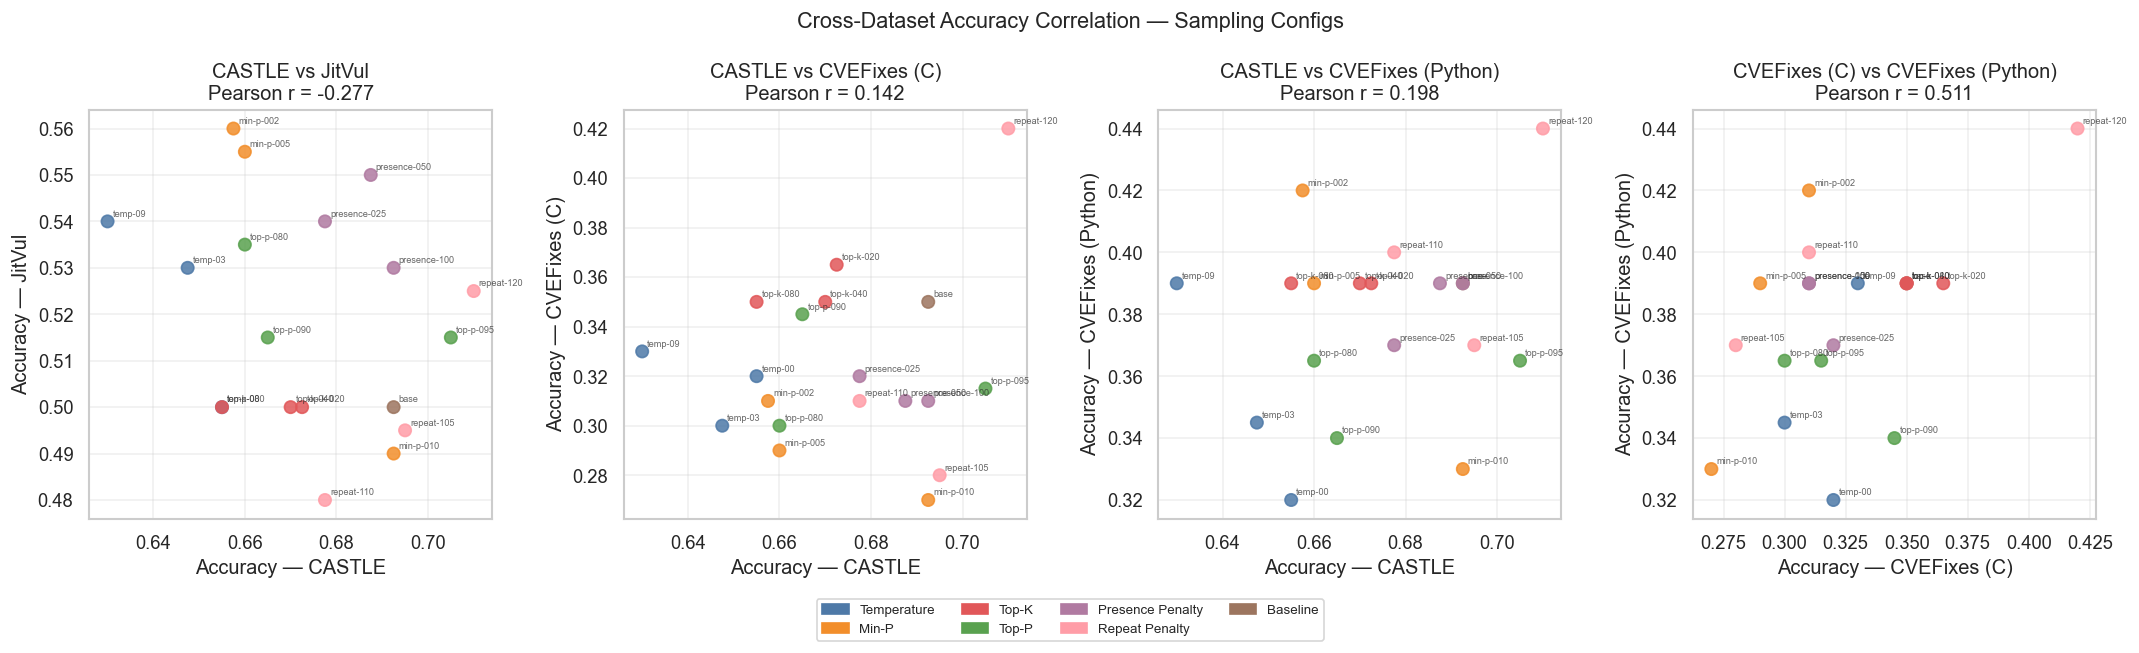

In [11]:
## Cross-dataset scatter — does a config that helps on one dataset also help on another?
## Each point = one sampling config; color = parameter type

CORR_PAIRS = [
    ('castle',        'jitvul'),
    ('castle',        'cvefixes_c'),
    ('castle',        'cvefixes_python'),
    ('cvefixes_c',    'cvefixes_python'),
]

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for ax, (ds1, ds2) in zip(axes, CORR_PAIRS):
    s1 = df[df['dataset'] == ds1][['model_name', 'param_type', 'accuracy', 'param_label']].rename(
        columns={'accuracy': 'acc1'})
    s2 = df[df['dataset'] == ds2][['model_name', 'accuracy']].rename(
        columns={'accuracy': 'acc2'})
    merged = s1.merge(s2, on='model_name').dropna(subset=['acc1', 'acc2'])
    if merged.empty:
        continue

    pt_colors = [PARAM_TYPE_COLORS.get(pt, '#9c755f') for pt in merged['param_type']]
    ax.scatter(merged['acc1'], merged['acc2'], c=pt_colors, s=55, alpha=0.85, zorder=3)

    for _, row in merged.iterrows():
        ax.annotate(row['param_label'], (row['acc1'], row['acc2']),
                    fontsize=5.5, alpha=0.7, xytext=(3, 3), textcoords='offset points')

    r = float(np.corrcoef(merged['acc1'], merged['acc2'])[0, 1])
    ax.set_xlabel(f'Accuracy — {DATASET_DISPLAY[ds1]}')
    ax.set_ylabel(f'Accuracy — {DATASET_DISPLAY[ds2]}')
    ax.set_title(f'{DATASET_DISPLAY[ds1]} vs {DATASET_DISPLAY[ds2]}\nPearson r = {r:.3f}')
    ax.grid(True, alpha=0.3)

patches = [mpatches.Patch(color=PARAM_TYPE_COLORS[pt], label=PARAM_TYPE_DISPLAY[pt])
           for pt in PARAM_TYPES_ORDERED]
patches.append(mpatches.Patch(color='#9c755f', label='Baseline'))
fig.legend(handles=patches, loc='lower center', ncol=4, fontsize=8,
           bbox_to_anchor=(0.5, -0.08))

fig.suptitle('Cross-Dataset Accuracy Correlation — Sampling Configs', fontsize=13)
fig.tight_layout()
plt.show()

## Token Usage

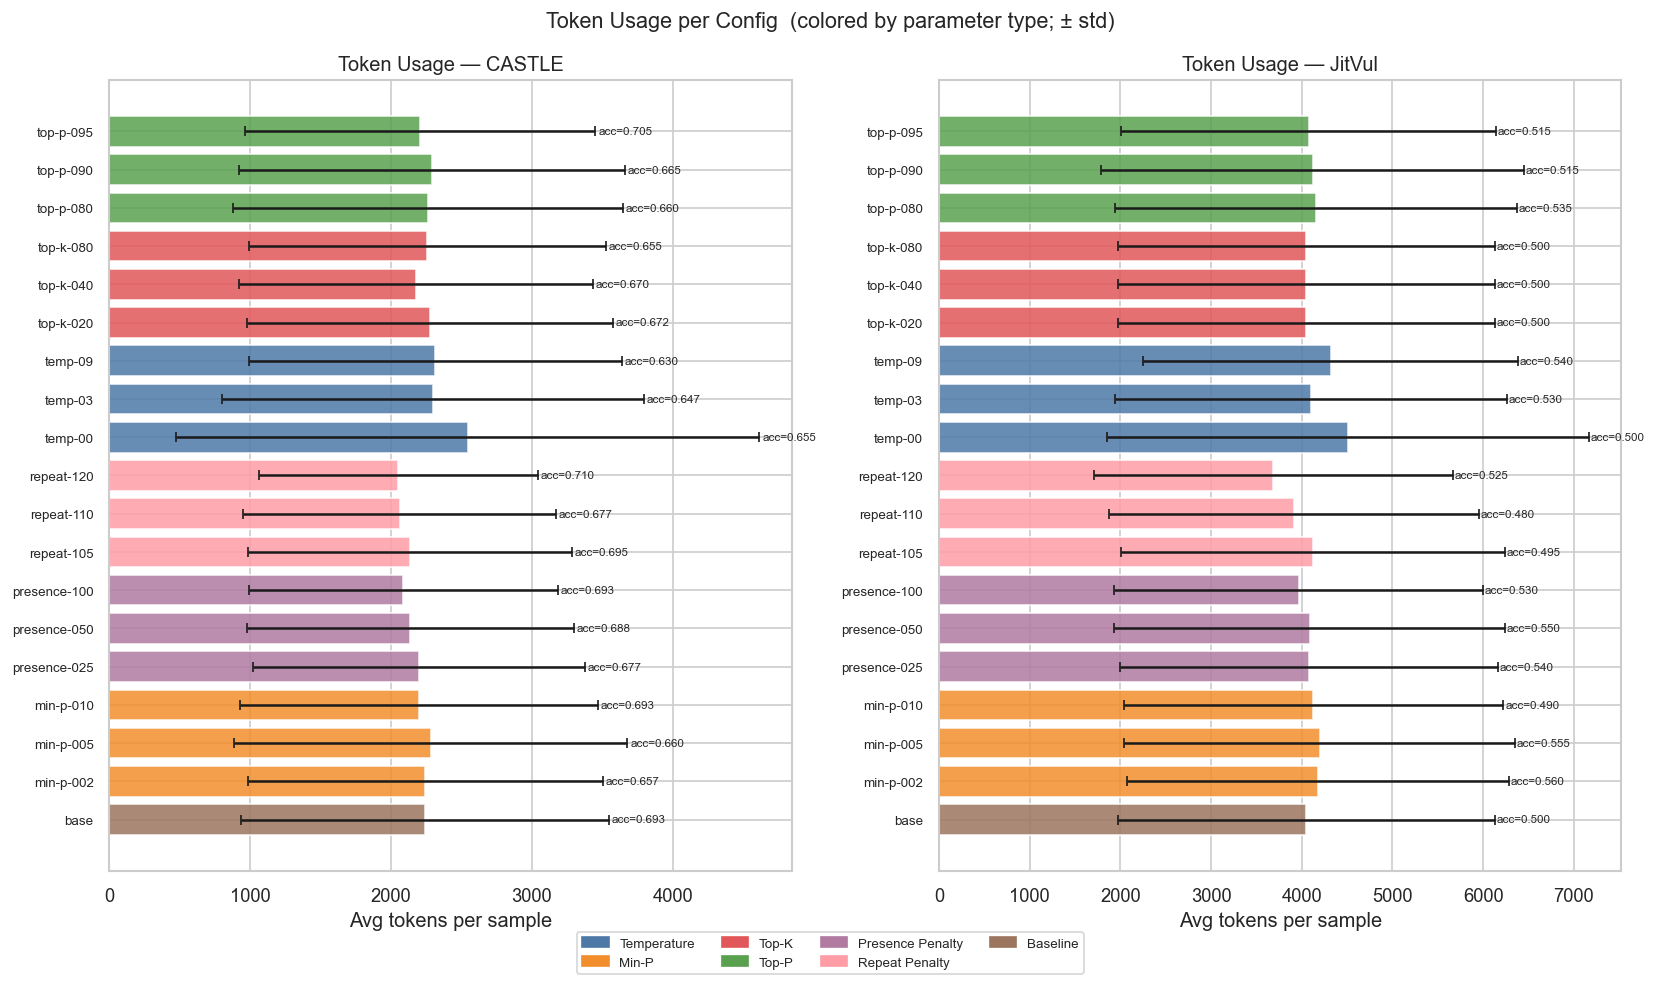

In [12]:
## Token usage per config, colored by parameter type — castle and jitvul (200 samples each)

fig, axes = plt.subplots(1, 2, figsize=(14, 8))

for ax, ds in zip(axes, ['castle', 'jitvul']):
    sub = (
        df[df['dataset'] == ds]
        .sort_values(['param_type', 'param_value'])
        .reset_index(drop=True)
    )
    colors = [PARAM_TYPE_COLORS.get(pt, '#9c755f') for pt in sub['param_type']]
    ax.barh(sub['param_label'], sub['tokens_avg'], xerr=sub['tokens_std'],
            color=colors, alpha=0.85, capsize=3)
    ax.set_xlabel('Avg tokens per sample')
    ax.set_title(f'Token Usage — {DATASET_DISPLAY[ds]}')
    ax.tick_params(axis='y', labelsize=8)
    # Add accuracy annotation at end of each bar
    for _, row in sub.iterrows():
        ax.text(row['tokens_avg'] + (row['tokens_std'] if not np.isnan(row['tokens_std']) else 0) + 20,
                sub.index[sub['param_label'] == row['param_label']].tolist()[0],
                f"acc={row['accuracy']:.3f}", va='center', fontsize=7)

patches = [mpatches.Patch(color=PARAM_TYPE_COLORS[pt], label=PARAM_TYPE_DISPLAY[pt])
           for pt in PARAM_TYPES_ORDERED]
patches.append(mpatches.Patch(color='#9c755f', label='Baseline'))
fig.legend(handles=patches, loc='lower center', ncol=4, fontsize=8,
           bbox_to_anchor=(0.5, -0.03))

fig.suptitle('Token Usage per Config  (colored by parameter type; ± std)', fontsize=13)
fig.tight_layout()
plt.show()

## Full Summary Table

In [13]:
## Styled summary — all aggregated configs, sorted by dataset then accuracy descending

SUMMARY_COLS = [
    'param_label', 'dataset_label',
    'accuracy', 'precision', 'recall', 'f1', 'specificity',
    'FNR', 'FPR', 'balanced_accuracy', 'MCC', 'youden_j',
    'delta_acc', 'delta_fnr',
    'TP', 'TN', 'FP', 'FN',
    'tokens_avg', 'time_avg', 'total_samples', 'n_runs',
]

summary = (
    df[SUMMARY_COLS]
    .sort_values(['dataset_label', 'accuracy'], ascending=[True, False])
    .reset_index(drop=True)
    .rename(columns={
        'param_label':   'Config',
        'dataset_label': 'Dataset',
        'tokens_avg':    'Tokens/sample',
        'time_avg':      'Sec/sample',
        'total_samples': 'N (total)',
        'n_runs':        'Runs',
    })
)

FLOAT_COLS  = ['accuracy', 'precision', 'recall', 'f1', 'specificity',
               'FNR', 'FPR', 'balanced_accuracy', 'MCC', 'youden_j']
DELTA_COLS  = ['delta_acc', 'delta_fnr']

display(
    summary.style
    .background_gradient(subset=FLOAT_COLS, cmap='RdYlGn', axis=0)
    .background_gradient(subset=DELTA_COLS, cmap='RdYlGn', axis=0, vmin=-0.06, vmax=0.06)
    .background_gradient(subset=['Runs'],   cmap='Blues',   axis=0)
    .format({c: '{:.3f}' for c in FLOAT_COLS})
    .format({c: '{:+.3f}' for c in DELTA_COLS})
    .format({'Tokens/sample': '{:,.0f}', 'Sec/sample': '{:.3f}', 'Runs': '{:.0f}'})
)

,Config,Dataset,accuracy,precision,recall,f1,specificity,FNR,FPR,balanced_accuracy,MCC,youden_j,delta_acc,delta_fnr,TP,TN,FP,FN,Tokens/sample,Sec/sample,N (total),Runs
0,repeat-120,CASTLE,0.710000,0.775862,0.737705,0.756303,0.666667,0.262295,0.333333,0.702186,0.399613,0.404372,0.017500,-0.062491,180,104,52,64,"2,051",1.341,400,2
1,top-p-095,CASTLE,0.705000,0.810526,0.652542,0.723005,0.780488,0.347458,0.219512,0.716515,0.426491,0.433030,0.012500,0.022671,154,128,36,82,"2,207",1.505,400,2
2,repeat-105,CASTLE,0.695000,0.777228,0.670940,0.720183,0.728916,0.329060,0.271084,0.699928,0.394055,0.399856,0.002500,0.004274,157,121,45,77,"2,134",1.470,400,2
3,base,CASTLE,0.692500,0.770732,0.675214,0.719818,0.716867,0.324786,0.283133,0.696041,0.386495,0.392081,0.000000,0.000000,158,119,47,76,"2,241",1.427,400,2
4,min-p-010,CASTLE,0.692500,0.790816,0.654008,0.715935,0.748466,0.345992,0.251534,0.701237,0.395607,0.402475,0.000000,0.021205,155,122,41,82,"2,198",1.516,400,2
5,presence-100,CASTLE,0.692500,0.774510,0.672340,0.719818,0.721212,0.327660,0.278788,0.696776,0.387557,0.393553,0.000000,0.002873,158,119,46,77,"2,088",1.357,400,2
6,presence-050,CASTLE,0.687500,0.771429,0.677824,0.721604,0.701863,0.322176,0.298137,0.689844,0.372865,0.379688,-0.005000,-0.002611,162,113,48,77,"2,136",1.472,400,2
7,presence-025,CASTLE,0.677500,0.764151,0.672199,0.715232,0.685535,0.327801,0.314465,0.678867,0.350768,0.357734,-0.015000,0.003015,162,109,50,79,"2,198",1.575,400,2
8,repeat-110,CASTLE,0.677500,0.745455,0.691983,0.717724,0.656442,0.308017,0.343558,0.674212,0.344136,0.348425,-0.015000,-0.016769,164,107,56,73,"2,060",1.347,400,2
9,top-k-020,CASTLE,0.672500,0.755981,0.663866,0.706935,0.685185,0.336134,0.314815,0.674525,0.343040,0.349051,-0.020000,0.011348,158,111,51,80,"2,275",1.455,400,2
